# Week 4: Spatial Feature Engineering

## Goals
- Read the cleaned Tokyo metropolitan population boundary data
- Load station point data
- Compute centroids of municipal polygons
- Calculate distance to the nearest station

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path


# Ensure src directory is in path for imports
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))

In [2]:
from tokyo_foreigners.paths import PROJECT_ROOT, DATA_RAW_DIR

# Standardize path variables using project module
project_root = PROJECT_ROOT
data_raw = DATA_RAW_DIR

print(project_root)
print(data_raw)

pop_path = data_raw / "tokyo_pop_dissolved.geojson"
tokyo_pop = gpd.read_file(pop_path)

print(tokyo_pop.shape)
print(tokyo_pop.crs)
tokyo_pop.head()

E:\rsch\laborJapan
E:\rsch\laborJapan\data_raw
(227, 8)
EPSG:6668


,N03_007,N03_001,N03_004,N03_005,total_pop,foreign_pop,foreign_ratio,geometry
0,11101,埼玉県,さいたま市,西区,95251,1469,0.015422410263409307,"MULTIPOLYGON (((139.54804 35.9341, 139.54823 3..."
1,11102,埼玉県,さいたま市,北区,150366,2775,0.01845496987350864,"POLYGON ((139.61753 35.96486, 139.61798 35.964..."
2,11103,埼玉県,さいたま市,大宮区,124703,3389,0.0271765715339647,"POLYGON ((139.63768 35.92278, 139.63804 35.922..."
3,11104,埼玉県,さいたま市,見沼区,165105,3594,0.02176796583992005,"POLYGON ((139.66718 35.96444, 139.66739 35.964..."
4,11105,埼玉県,さいたま市,中央区,103107,2061,0.019988943524687944,"POLYGON ((139.62232 35.90225, 139.62277 35.901..."


In [5]:
tokyo_pop_proj = tokyo_pop.to_crs(epsg=6677)
print(tokyo_pop_proj.crs)

EPSG:6677


In [6]:
tokyo_pop_proj["centroid"] = tokyo_pop_proj.geometry.centroid
tokyo_centroids = tokyo_pop_proj.copy()
tokyo_centroids = tokyo_centroids.set_geometry("centroid")

print(tokyo_centroids.shape)
tokyo_centroids.head()

(227, 9)


,N03_007,N03_001,N03_004,N03_005,total_pop,foreign_pop,foreign_ratio,geometry,centroid
0,11101,埼玉県,さいたま市,西区,95251,1469,0.015422410263409307,"MULTIPOLYGON (((-25741.989 -7274.146, -25724.9...",POINT (-23317.549 -10030.157)
1,11102,埼玉県,さいたま市,北区,150366,2775,0.01845496987350864,"POLYGON ((-19464.582 -3877.533, -19423.753 -38...",POINT (-19689.121 -6733.246)
2,11103,埼玉県,さいたま市,大宮区,124703,3389,0.0271765715339647,"POLYGON ((-17656.644 -8549.615, -17623.916 -85...",POINT (-18907.834 -10357.563)
3,11104,埼玉県,さいたま市,見沼区,165105,3594,0.02176796583992005,"POLYGON ((-14986.573 -3932.152, -14966.946 -39...",POINT (-15073.645 -8078.831)
4,11105,埼玉県,さいたま市,中央区,103107,2061,0.019988943524687944,"POLYGON ((-19047.367 -10824.812, -19007.183 -1...",POINT (-18832.133 -13146.806)


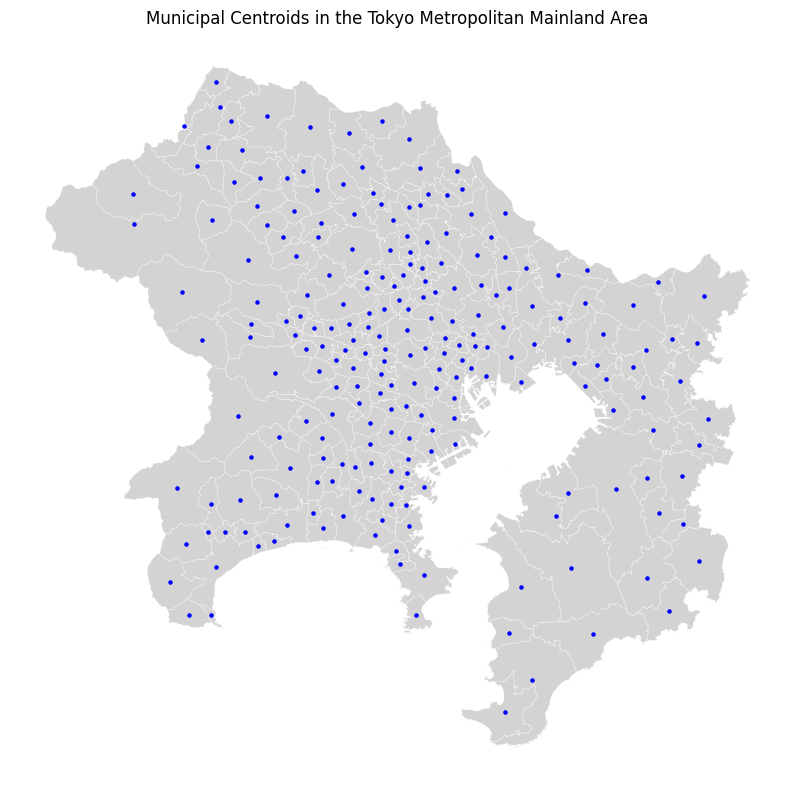

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))

tokyo_pop_proj.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.2)
tokyo_centroids.plot(ax=ax, color="blue", markersize=5)

ax.set_title("Municipal Centroids in the Tokyo Metropolitan Mainland Area")
ax.set_axis_off()
plt.show()

In [8]:
station_path = data_raw / "N02-22_GML" / "UTF-8" / "N02-22_Station.shp"
print("station_path:", station_path)
print("exists:", station_path.exists())

stations = gpd.read_file(station_path)

print(stations.shape)
print(stations.crs)
stations.head()

station_path: e:\rsch\laborJapan\data_raw\N02-22_GML\UTF-8\N02-22_Station.shp
exists: True
(10220, 8)
EPSG:6668


,N02_001,N02_002,N02_003,N02_004,N02_005,N02_005c,N02_005g,geometry
0,11,2,æå®¿æå´ç·,ä¹å·æ å®¢éé,äºæç°,010112,010112,"LINESTRING (130.63035 31.25405, 130.62985 31.2..."
1,23,5,æ²ç¸é½å¸ã¢ãã¬ã¼ã«ç·,æ²ç¸é½å¸ã¢ãã¬ã¼ã«,å¤å³¶,010127,010127,"LINESTRING (127.70279 26.23035, 127.70309 26.2..."
2,24,5,æ±äº¬è¨æµ·æ°äº¤éè¨æµ·ç·,ããããã,ãå°å ´æµ·æµå ¬å,004091,004091,"LINESTRING (139.77818 35.62961, 139.77888 35.63)"
3,24,5,æ±äº¬è¨æµ·æ°äº¤éè¨æµ·ç·,ããããã,æ±äº¬å½éã¯ã«ã¼ãºã¿ã¼ããã«,004128,004128,"LINESTRING (139.77333 35.62109, 139.77288 35.6..."
4,24,5,æ±äº¬è¨æµ·æ°äº¤éè¨æµ·ç·,ããããã,ãã¬ã³ã ã»ã³ã¿ã¼,004144,004144,"LINESTRING (139.78001 35.61791, 139.77932 35.6..."


In [9]:
print(stations.columns.tolist())
stations.head(3).T

['N02_001', 'N02_002', 'N02_003', 'N02_004', 'N02_005', 'N02_005c', 'N02_005g', 'geometry']


,0,1,2
N02_001,11,23,24
N02_002,2,5,5
N02_003,æå®¿æå´ç·,æ²ç¸é½å¸ã¢ãã¬ã¼ã«ç·,æ±äº¬è¨æµ·æ°äº¤éè¨æµ·ç·
N02_004,ä¹å·æ å®¢éé,æ²ç¸é½å¸ã¢ãã¬ã¼ã«,ããããã
N02_005,äºæç°,å¤å³¶,ãå°å ´æµ·æµå ¬å
N02_005c,010112,010127,004091
N02_005g,010112,010127,004091
geometry,"LINESTRING (130.63035 31.25405, 130.62985 31.2...","LINESTRING (127.70279 26.23035, 127.70309 26.2...","LINESTRING (139.77818 35.62961, 139.77888 35.63)"


In [10]:
stations_proj = stations.to_crs(epsg=6677)
print(stations_proj.crs)

EPSG:6677


In [11]:
nearest_station = gpd.sjoin_nearest(
    tokyo_centroids,
    stations_proj,
    how="left",
    distance_col="dist_to_station_m"
)

print(nearest_station.shape)
nearest_station.head()

(244, 18)


,N03_007,N03_001,N03_004,N03_005,total_pop,foreign_pop,foreign_ratio,geometry,centroid,index_right,N02_001,N02_002,N02_003,N02_004,N02_005,N02_005c,N02_005g,dist_to_station_m
0,11101,埼玉県,さいたま市,西区,95251,1469,0.015422410263409307,"MULTIPOLYGON (((-25741.989 -7274.146, -25724.9...",POINT (-23317.549 -10030.157),7327,11,2,å·è¶ç·,æ±æ¥æ¬æ å®¢éé,ææ,002891,002891,1217.639796
1,11102,埼玉県,さいたま市,北区,150366,2775,0.01845496987350864,"POLYGON ((-19464.582 -3877.533, -19423.753 -38...",POINT (-19689.121 -6733.246),2399,16,5,ä¼å¥ç·,å¼çæ°é½å¸äº¤é,å èå®®,002857,002857,376.317982
2,11103,埼玉県,さいたま市,大宮区,124703,3389,0.0271765715339647,"POLYGON ((-17656.644 -8549.615, -17623.916 -85...",POINT (-18907.834 -10357.563),7855,11,2,æ±åç·,æ±æ¥æ¬æ å®¢éé,å¤§å®®,002912,002914,18.735225
3,11104,埼玉県,さいたま市,見沼区,165105,3594,0.02176796583992005,"POLYGON ((-14986.573 -3932.152, -14966.946 -39...",POINT (-15073.645 -8078.831),8415,12,4,éç°ç·,æ±æ­¦éé,ä¸é,002854,002854,1005.052129
4,11105,埼玉県,さいたま市,中央区,103107,2061,0.019988943524687944,"POLYGON ((-19047.367 -10824.812, -19007.183 -1...",POINT (-18832.133 -13146.806),7841,11,2,æ±åç·,æ±æ¥æ¬æ å®¢éé,ä¸éæ¬çº,002951,002951,94.227971


In [12]:
nearest_station = nearest_station.drop_duplicates(subset=["N03_007"]).copy()

print(nearest_station.shape)
nearest_station[["N03_001", "N03_004", "N03_005", "N03_007", "dist_to_station_m"]].head(10)

(227, 18)


,N03_001,N03_004,N03_005,N03_007,dist_to_station_m
0,埼玉県,さいたま市,西区,11101,1217.639796
1,埼玉県,さいたま市,北区,11102,376.317982
2,埼玉県,さいたま市,大宮区,11103,18.735225
3,埼玉県,さいたま市,見沼区,11104,1005.052129
4,埼玉県,さいたま市,中央区,11105,94.227971
5,埼玉県,さいたま市,桜区,11106,2284.976970
6,埼玉県,さいたま市,浦和区,11107,640.001061
7,埼玉県,さいたま市,南区,11108,732.620522
8,埼玉県,さいたま市,緑区,11109,2273.705911
9,埼玉県,さいたま市,岩槻区,11110,1896.568286


In [13]:
tokyo_pop_proj["dist_to_station_m"] = tokyo_pop_proj["N03_007"].map(
    nearest_station.set_index("N03_007")["dist_to_station_m"]
)

print(tokyo_pop_proj[["N03_007", "foreign_ratio", "dist_to_station_m"]].head())
print("Missing distances:", tokyo_pop_proj["dist_to_station_m"].isna().sum())

  N03_007         foreign_ratio  dist_to_station_m
0   11101  0.015422410263409307        1217.639796
1   11102   0.01845496987350864         376.317982
2   11103    0.0271765715339647          18.735225
3   11104   0.02176796583992005        1005.052129
4   11105  0.019988943524687944          94.227971
Missing distances: 0


In [14]:
tokyo_pop_proj[
    tokyo_pop_proj["N03_004"].astype(str).str.contains("川口|江戸川", na=False) |
    tokyo_pop_proj["N03_005"].astype(str).str.contains("川口|江戸川", na=False)
][["N03_001", "N03_004", "N03_005", "N03_007", "foreign_ratio", "dist_to_station_m"]]

,N03_001,N03_004,N03_005,N03_007,foreign_ratio,dist_to_station_m
12,埼玉県,川口市,,11203,0.07113134261893571,300.302318
138,東京都,江戸川区,,13123,0.06220351585089592,919.207429


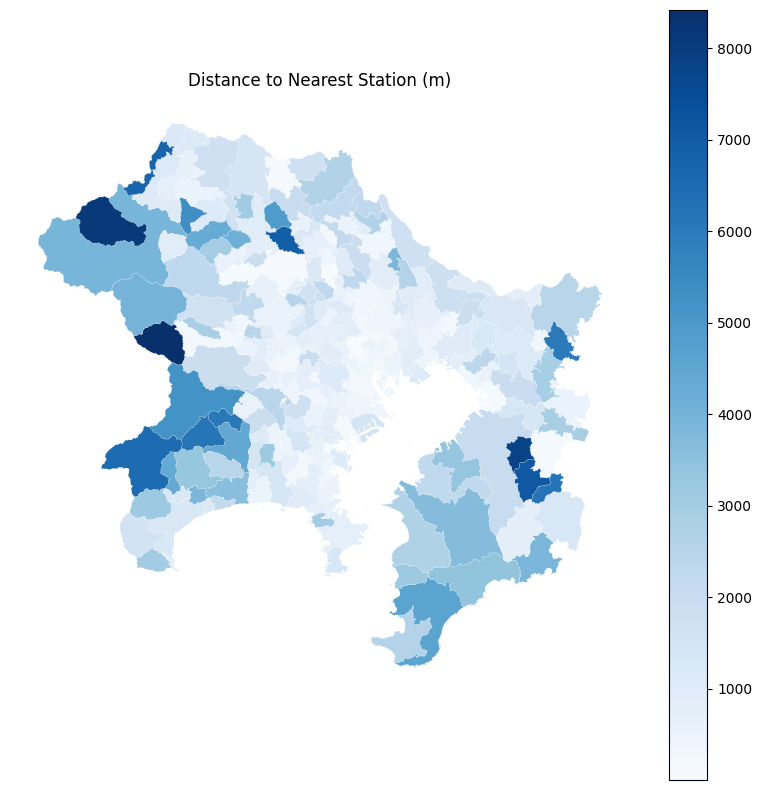

In [15]:
fig, ax = plt.subplots(figsize=(10, 10))

tokyo_pop_proj.plot(
    column="dist_to_station_m",
    cmap="Blues",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    ax=ax
)

ax.set_title("Distance to Nearest Station (m)")
ax.set_axis_off()
plt.show()

In [16]:
tokyo_pop_proj["nearest_station_name"] = tokyo_pop_proj["N03_007"].map(
    nearest_station.set_index("N03_007")["N02_005"]
)

In [17]:
print(tokyo_pop_proj[["N03_007", "foreign_ratio", "dist_to_station_m"]].head())

  N03_007         foreign_ratio  dist_to_station_m
0   11101  0.015422410263409307        1217.639796
1   11102   0.01845496987350864         376.317982
2   11103    0.0271765715339647          18.735225
3   11104   0.02176796583992005        1005.052129
4   11105  0.019988943524687944          94.227971


In [18]:
print("Missing distances:", tokyo_pop_proj["dist_to_station_m"].isna().sum())

Missing distances: 0


In [19]:
tokyo_pop_proj[
    tokyo_pop_proj["N03_004"].astype(str).str.contains("川口|江戸川", na=False) |
    tokyo_pop_proj["N03_005"].astype(str).str.contains("川口|江戸川", na=False)
][["N03_001", "N03_004", "N03_005", "N03_007", "foreign_ratio", "dist_to_station_m"]]

,N03_001,N03_004,N03_005,N03_007,foreign_ratio,dist_to_station_m
12,埼玉県,川口市,,11203,0.07113134261893571,300.302318
138,東京都,江戸川区,,13123,0.06220351585089592,919.207429


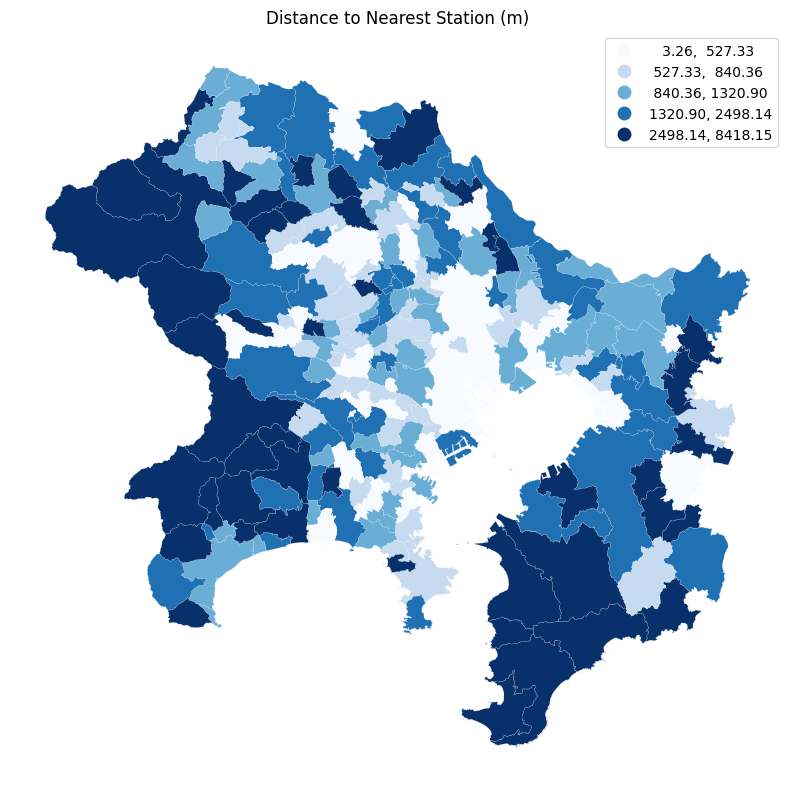

In [20]:
fig, ax = plt.subplots(figsize=(10, 10))

tokyo_pop_proj.plot(
    column="dist_to_station_m",
    cmap="Blues",
    scheme="Quantiles",
    k=5,
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    ax=ax
)

ax.set_title("Distance to Nearest Station (m)")
ax.set_axis_off()
plt.show()

In [22]:
station_path_sjis = data_raw / "N02-22_GML" / "Shift-JIS" / "N02-22_Station.shp"
print("exists:", station_path_sjis.exists())

stations_clean = gpd.read_file(station_path_sjis, encoding="cp932")

print(stations_clean.shape)
print(stations_clean.crs)
print(stations_clean.columns.tolist())
stations_clean.head(3).T

exists: True
(10220, 8)
EPSG:6668
['N02_001', 'N02_002', 'N02_003', 'N02_004', 'N02_005', 'N02_005c', 'N02_005g', 'geometry']


,0,1,2
N02_001,11,23,24
N02_002,2,5,5
N02_003,指宿枕崎線,沖縄都市モノレール線,東京臨海新交通臨海線
N02_004,九州旅客鉄道,沖縄都市モノレール,ゆりかもめ
N02_005,二月田,古島,お台場海浜公園
N02_005c,010112,010127,004091
N02_005g,010112,010127,004091
geometry,"LINESTRING (130.63035 31.25405, 130.62985 31.2...","LINESTRING (127.70279 26.23035, 127.70309 26.2...","LINESTRING (139.77818 35.62961, 139.77888 35.63)"


In [23]:
stations_clean_proj = stations_clean.to_crs(epsg=6677)

In [24]:
nearest_station_clean = gpd.sjoin_nearest(
    tokyo_centroids,
    stations_clean_proj,
    how="left",
    distance_col="dist_to_station_m"
)

nearest_station_clean = nearest_station_clean.drop_duplicates(subset=["N03_007"]).copy()

In [25]:
tokyo_pop_proj["nearest_station_name"] = tokyo_pop_proj["N03_007"].map(
    nearest_station_clean.set_index("N03_007")["N02_005"]
)

In [26]:
tokyo_pop_proj["nearest_line_name"] = tokyo_pop_proj["N03_007"].map(
    nearest_station_clean.set_index("N03_007")["N02_003"]
)

In [27]:
tokyo_pop_proj["nearest_operator"] = tokyo_pop_proj["N03_007"].map(
    nearest_station_clean.set_index("N03_007")["N02_004"]
)

In [28]:
tokyo_pop_proj[["N03_007", "nearest_station_name", "nearest_line_name"]].head(10)

,N03_007,nearest_station_name,nearest_line_name
0,11101,指扇,川越線
1,11102,加茂宮,伊奈線
2,11103,大宮,東北線
3,11104,七里,野田線
4,11105,与野本町,東北線
5,11106,南与野,東北線
6,11107,北浦和,東北線
7,11108,南浦和,武蔵野線
8,11109,東浦和,武蔵野線
9,11110,岩槻,野田線


In [29]:
tokyo_pop_proj[
    tokyo_pop_proj["N03_004"].astype(str).str.contains("川口|江戸川", na=False) |
    tokyo_pop_proj["N03_005"].astype(str).str.contains("川口|江戸川", na=False)
][["N03_001", "N03_004", "N03_005", "dist_to_station_m", "nearest_station_name", "nearest_line_name"]]

,N03_001,N03_004,N03_005,dist_to_station_m,nearest_station_name,nearest_line_name
12,埼玉県,川口市,,300.302318,鳩ヶ谷,埼玉高速鉄道線
138,東京都,江戸川区,,919.207429,一之江,10号線新宿線


In [30]:
tokyo_station_features_path = data_raw / "tokyo_pop_with_station_features.geojson"
tokyo_pop_proj.to_file(tokyo_station_features_path, driver="GeoJSON")

print(tokyo_station_features_path)
print(tokyo_station_features_path.exists())

ValueError: GeoDataFrame contains multiple geometry columns but GeoDataFrame.to_file supports only a single geometry column. Use a GeoDataFrame.to_parquet or GeoDataFrame.to_feather, drop additional geometry columns or convert them to a supported format like a well-known text (WKT) using `GeoSeries.to_wkt()`.

In [31]:
tokyo_save = tokyo_pop_proj.drop(columns=["centroid"]).copy()

tokyo_station_features_path = data_raw / "tokyo_pop_with_station_features.geojson"
tokyo_save.to_file(tokyo_station_features_path, driver="GeoJSON")

print(tokyo_station_features_path)
print(tokyo_station_features_path.exists())

e:\rsch\laborJapan\data_raw\tokyo_pop_with_station_features.geojson
True


In [32]:
tokyo_save.drop(columns="geometry").to_csv(
    data_raw / "tokyo_pop_with_station_features.csv",
    index=False,
    encoding="utf-8-sig"
)

In [33]:
tokyo_save["dist_to_station_m"].describe()

count     227.000000
mean     1637.975651
std      1640.823796
min         3.260248
25%       575.631799
50%      1019.045177
75%      2205.548485
max      8418.151585
Name: dist_to_station_m, dtype: float64

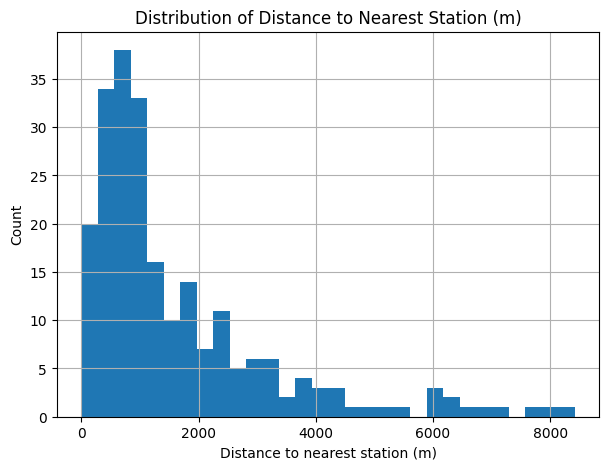

In [34]:
fig, ax = plt.subplots(figsize=(7, 5))

tokyo_save["dist_to_station_m"].hist(bins=30, ax=ax)

ax.set_title("Distribution of Distance to Nearest Station (m)")
ax.set_xlabel("Distance to nearest station (m)")
ax.set_ylabel("Count")

plt.show()

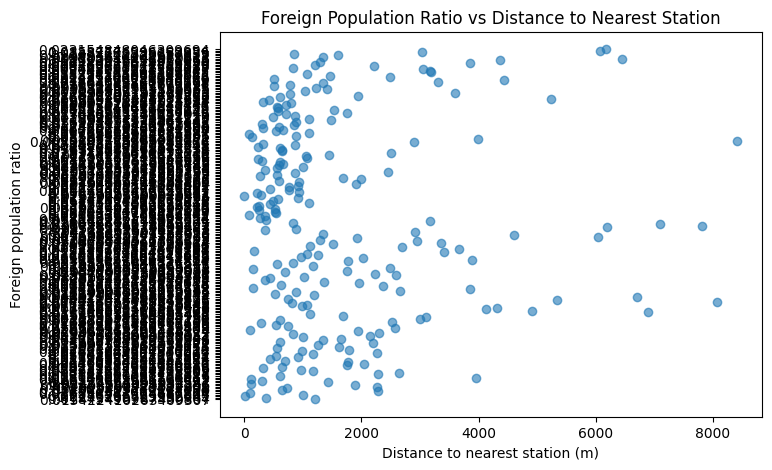

In [35]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    tokyo_save["dist_to_station_m"],
    tokyo_save["foreign_ratio"],
    alpha=0.6
)

ax.set_xlabel("Distance to nearest station (m)")
ax.set_ylabel("Foreign population ratio")
ax.set_title("Foreign Population Ratio vs Distance to Nearest Station")

plt.show()

In [36]:
print(tokyo_save["foreign_ratio"].dtype)
print(tokyo_save["foreign_ratio"].head())

str
0    0.015422410263409307
1     0.01845496987350864
2      0.0271765715339647
3     0.02176796583992005
4    0.019988943524687944
Name: foreign_ratio, dtype: str


In [37]:
tokyo_save["foreign_ratio"] = pd.to_numeric(tokyo_save["foreign_ratio"], errors="coerce")
print(tokyo_save["foreign_ratio"].dtype)
print(tokyo_save["foreign_ratio"].isna().sum())

float64
0


In [38]:
tokyo_save["dist_to_station_m"] = pd.to_numeric(tokyo_save["dist_to_station_m"], errors="coerce")

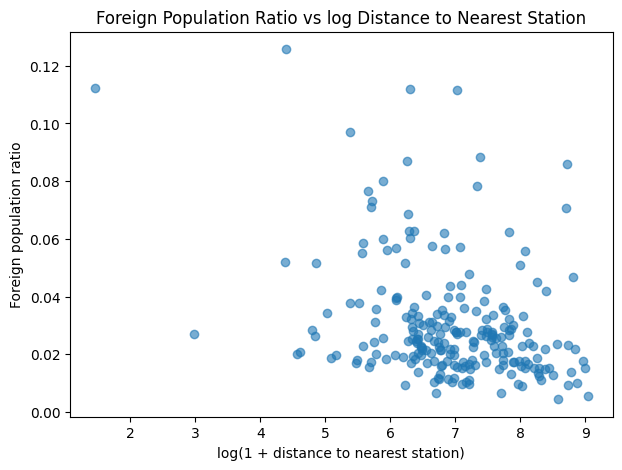

In [39]:
import numpy as np

tokyo_save["log_dist_to_station_m"] = np.log1p(tokyo_save["dist_to_station_m"])

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    tokyo_save["log_dist_to_station_m"],
    tokyo_save["foreign_ratio"],
    alpha=0.6
)

ax.set_xlabel("log(1 + distance to nearest station)")
ax.set_ylabel("Foreign population ratio")
ax.set_title("Foreign Population Ratio vs log Distance to Nearest Station")

plt.show()

In [40]:
corr_raw = tokyo_save[["foreign_ratio", "dist_to_station_m"]].corr().iloc[0, 1]
corr_log = tokyo_save[["foreign_ratio", "log_dist_to_station_m"]].corr().iloc[0, 1]

print("Correlation with raw distance:", corr_raw)
print("Correlation with log distance:", corr_log)

Correlation with raw distance: -0.20819504770099553
Correlation with log distance: -0.3332948331948089


In [41]:
eda_df = tokyo_save[["foreign_ratio", "dist_to_station_m", "log_dist_to_station_m"]].copy()
eda_df.corr()

,foreign_ratio,dist_to_station_m,log_dist_to_station_m
foreign_ratio,1.000000,-0.208195,-0.333295
dist_to_station_m,-0.208195,1.000000,0.817114
log_dist_to_station_m,-0.333295,0.817114,1.000000


In [42]:
eda_df = tokyo_save[["foreign_ratio", "dist_to_station_m", "log_dist_to_station_m"]].copy()
eda_df.corr()

,foreign_ratio,dist_to_station_m,log_dist_to_station_m
foreign_ratio,1.000000,-0.208195,-0.333295
dist_to_station_m,-0.208195,1.000000,0.817114
log_dist_to_station_m,-0.333295,0.817114,1.000000


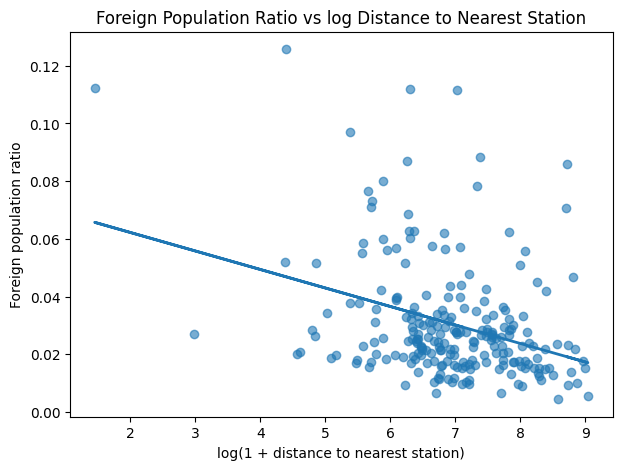

In [43]:
fig, ax = plt.subplots(figsize=(7, 5))

x = tokyo_save["log_dist_to_station_m"]
y = tokyo_save["foreign_ratio"]

ax.scatter(x, y, alpha=0.6)

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
ax.plot(x, p(x), linewidth=2)

ax.set_xlabel("log(1 + distance to nearest station)")
ax.set_ylabel("Foreign population ratio")
ax.set_title("Foreign Population Ratio vs log Distance to Nearest Station")

plt.show()

In [44]:
tokyo_save_path = data_raw / "tokyo_features_v1.geojson"
tokyo_save.to_file(tokyo_save_path, driver="GeoJSON")

tokyo_save.drop(columns="geometry").to_csv(
    data_raw / "tokyo_features_v1.csv",
    index=False,
    encoding="utf-8-sig"
)